## Part 1: Import Required Libraries

In [8]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Model saving
import pickle
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 2: Load and Understand the Dataset

In [29]:
# Load the dataset
df = pd.read_excel('data.xlsx')

# Display first few rows
print("FIRST 5 ROWS OF DATASET")
print(df.head())
# Display dataset shape
print(f"DATASET SHAPE: {df.shape}")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")


FIRST 5 ROWS OF DATASET
   User ID  Gender  Age  Estimated Salary  Time Spent On Site (min)  \
0     1001    Male   22             28000                         6   
1     1002  Female   35             62000                        19   
2     1003    Male   27             41000                        12   
3     1004  Female   45             87000                        28   
4     1005    Male   31             52000                        15   

   Pages Visited  Previous Purchases Device Type Location Purchased?  
0              3                   0      Mobile    Tier3     No (0)  
1             10                   4     Desktop    Tier1    Yes (1)  
2              6                   1      Tablet    Tier2     No (0)  
3             16                   7     Desktop    Tier1    Yes (1)  
4              8                   2      Mobile    Tier2    Yes (1)  
DATASET SHAPE: (100, 10)
Total Rows: 100, Total Columns: 10


In [ ]:
# Clean column names - remove spaces and standardize
df.columns = df.columns.str.replace(' ', '')
df = df.rename(columns={
    'UserID': 'User_ID',
    'EstimatedSalary': 'EstimatedSalary',
    'TimeSpentOnSite(min)': 'TimeSpentOnSite',
    'PagesVisited': 'PagesVisited',
    'PreviousPurchases': 'PreviousPurchases',
    'DeviceType': 'DeviceType',
    'Purchased?': 'Purchased'
})

# Convert target variable to binary (0/1)
df['Purchased'] = df['Purchased'].astype(str).str.strip()
df['Purchased'] = df['Purchased'].map({
    'No (0)': 0, 'Yes (1)': 1,
    'No': 0, 'Yes': 1,
    '0': 0, '1': 1
})

print("CLEANED COLUMN NAMES")
print(df.columns.tolist())
print(f"\nTarget variable unique values: {df['Purchased'].unique()}")
print(f"Target variable value counts:\n{df['Purchased'].value_counts()}")

CLEANED COLUMN NAMES
['User_ID', 'Gender', 'Age', 'EstimatedSalary', 'TimeSpentOnSite', 'PagesVisited', 'PreviousPurchases', 'DeviceType', 'Location', 'Purchased']

Target variable unique values: [0 1]
Target variable value counts:
Purchased
1    51
0    49
Name: count, dtype: int64


In [16]:
# Display data types
print("DATA TYPES")
print(df.dtypes)

# Check for null values
print("NULL VALUES")
print(df.isnull().sum())

# Check for any null values
if df.isnull().sum().sum() == 0:
    print("\n No missing values found in the dataset!")

DATA TYPES
User_ID                int64
Gender                   str
Age                    int64
EstimatedSalary        int64
TimeSpentOnSite        int64
PagesVisited           int64
PreviousPurchases      int64
DeviceType               str
Location                 str
Purchased            float64
dtype: object
NULL VALUES
User_ID                0
Gender                 0
Age                    0
EstimatedSalary        0
TimeSpentOnSite        0
PagesVisited           0
PreviousPurchases      0
DeviceType             0
Location               0
Purchased            100
dtype: int64


In [17]:
# Statistical summary

print("STATISTICAL SUMMARY")
print(df.describe())

# Display information about the dataset
print("DATASET INFO")
df.info()

STATISTICAL SUMMARY
           User_ID        Age  EstimatedSalary  TimeSpentOnSite  PagesVisited  \
count   100.000000  100.00000       100.000000       100.000000    100.000000   
mean   1050.500000   33.53000     59310.000000        17.930000      9.770000   
std      29.011492    7.58448     20469.585716         7.945846      5.167605   
min    1001.000000   22.00000     28000.000000         6.000000      3.000000   
25%    1025.750000   27.00000     42000.000000        11.000000      5.000000   
50%    1050.500000   32.00000     55000.000000        16.000000      8.000000   
75%    1075.250000   40.00000     76500.000000        24.250000     14.250000   
max    1100.000000   50.00000     98000.000000        33.000000     20.000000   

       PreviousPurchases  Purchased  
count         100.000000        0.0  
mean            3.560000        NaN  
std             2.945018        NaN  
min             0.000000        NaN  
25%             1.000000        NaN  
50%             3.0000

In [19]:
# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("FEATURE IDENTIFICATION")
print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)
print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)
print(f"\nTarget Variable: Purchased")

# Remove User_ID from numerical features as it's an identifier, not a feature
if 'User_ID' in numerical_features:
    numerical_features.remove('User_ID')
    
# Remove Purchased from numerical features as it's our target
if 'Purchased' in numerical_features:
    numerical_features.remove('Purchased')
    
print(f"\nActual Numerical Features for Analysis: {numerical_features}")

FEATURE IDENTIFICATION

Numerical Features (7):
['User_ID', 'Age', 'EstimatedSalary', 'TimeSpentOnSite', 'PagesVisited', 'PreviousPurchases', 'Purchased']

Categorical Features (3):
['Gender', 'DeviceType', 'Location']

Target Variable: Purchased

Actual Numerical Features for Analysis: ['Age', 'EstimatedSalary', 'TimeSpentOnSite', 'PagesVisited', 'PreviousPurchases']


## Part 3: Exploratory Data Analysis (EDA)

CLASS DISTRIBUTION (Target Variable)
Purchased
1    51
0    49
Name: count, dtype: int64

Percentage Distribution:
Purchased
1    51.0
0    49.0
Name: proportion, dtype: float64


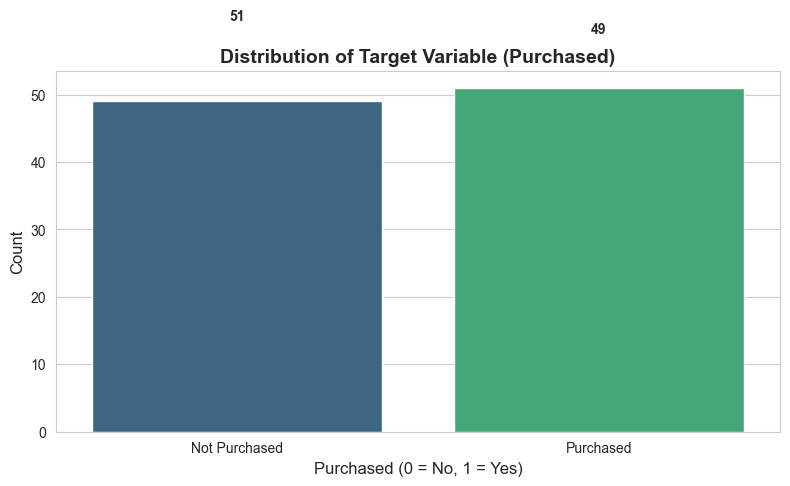

In [31]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Check class imbalance
print("CLASS DISTRIBUTION (Target Variable)")
print(df['Purchased'].value_counts())
print("\nPercentage Distribution:")
print(df['Purchased'].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Purchased', palette='viridis')
plt.title('Distribution of Target Variable (Purchased)', fontsize=14, fontweight='bold')
plt.xlabel('Purchased (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])
for i, v in enumerate(df['Purchased'].value_counts().values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

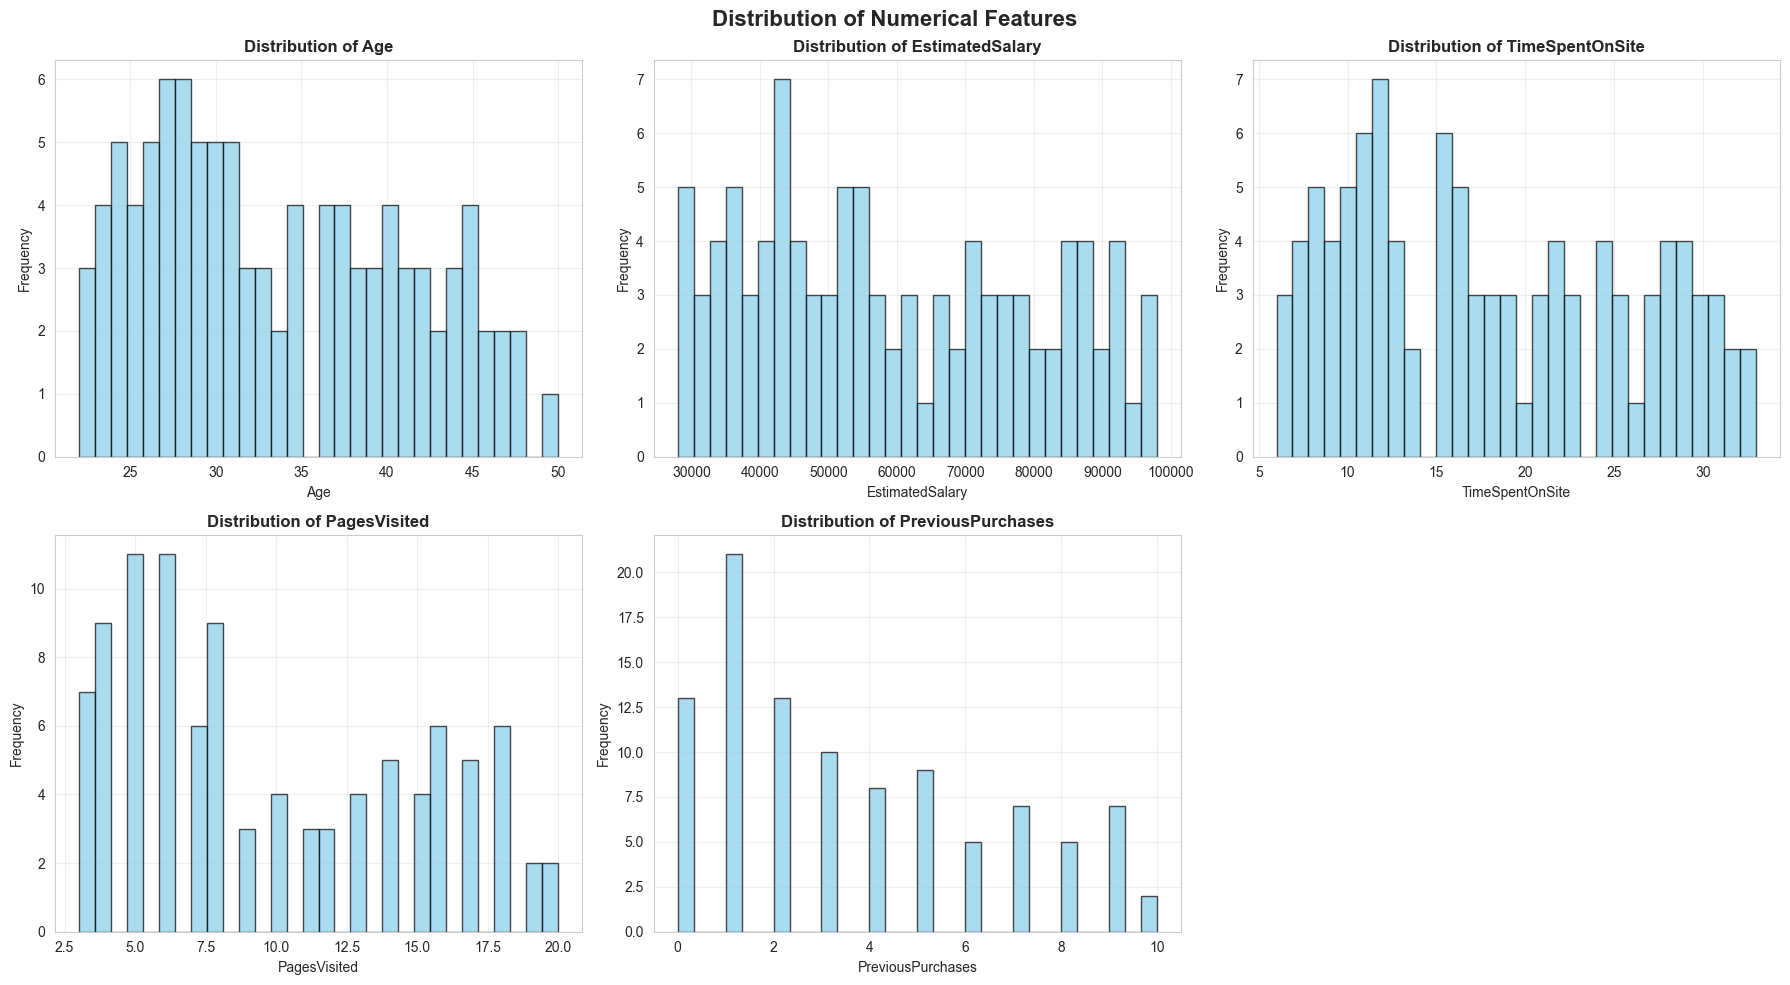

In [21]:
# Distribution of Numerical Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numerical_cols = ['Age', 'EstimatedSalary', 'TimeSpentOnSite', 'PagesVisited', 'PreviousPurchases']

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

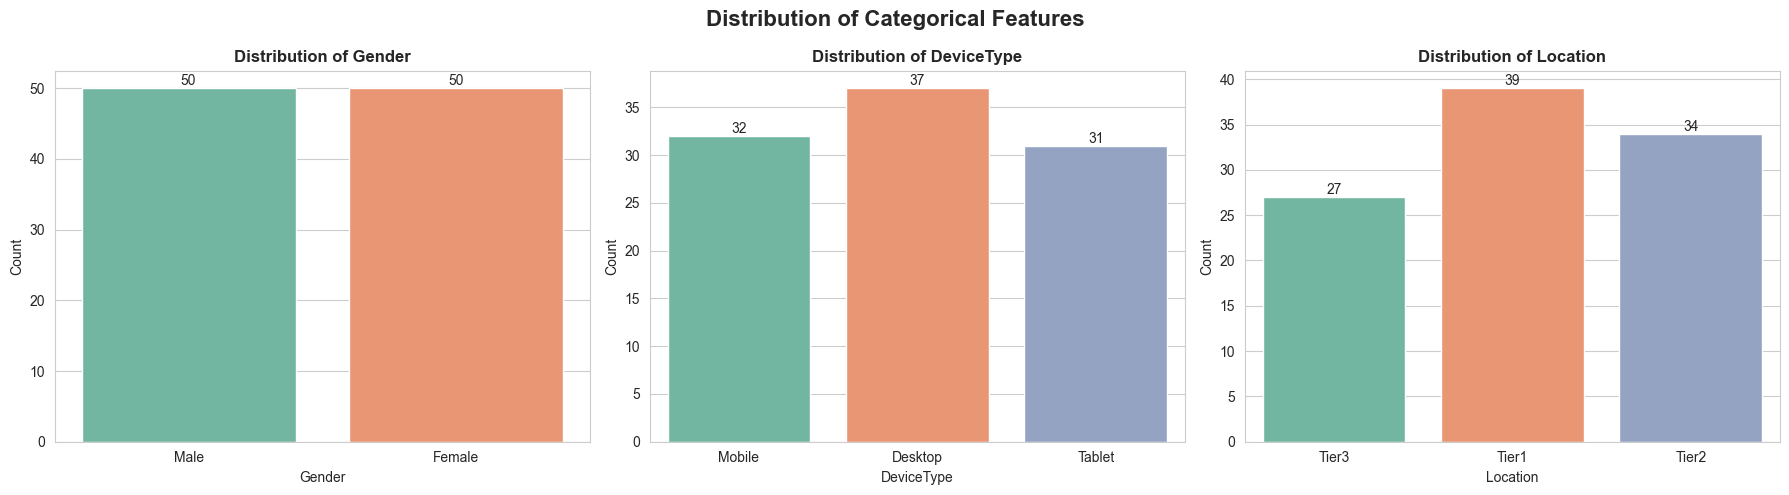

In [22]:
# Distribution of Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

categorical_cols = ['Gender', 'DeviceType', 'Location']

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, palette='Set2', ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    
    # Add value labels on bars
    for container in axes[idx].containers:
        axes[idx].bar_label(container)

plt.tight_layout()
plt.show()

AGE GROUP ANALYSIS
          Total_Purchases  Total_Customers  Purchase_Rate
AgeGroup                                                 
20-25                   0               16           0.00
26-35                  11               44           0.25
36-45                  33               33           1.00
46-55                   7                7           1.00


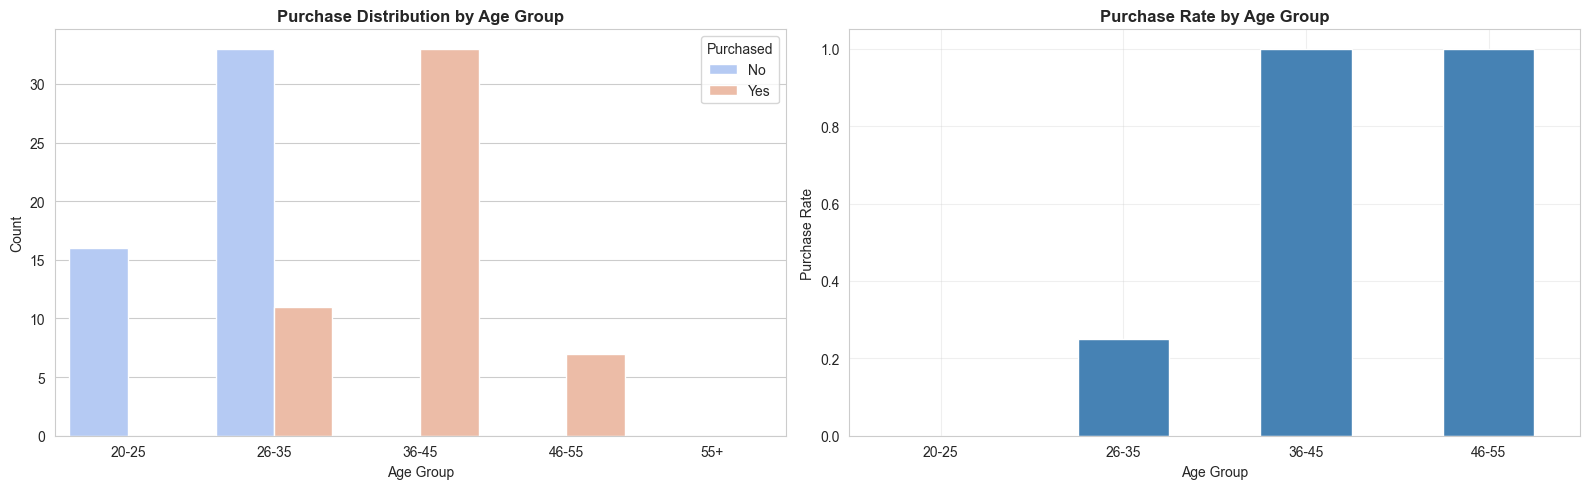


ge group with highest purchases: 36-45


In [55]:
# Question 1: Which age group purchases the most?
print("AGE GROUP ANALYSIS")

# Age groups with proper bins matching data range (ages 22-50)
df['AgeGroup'] = pd.cut(df['Age'], 
                        bins=[20, 25, 35, 45, 55, 100], 
                        labels=['20-25', '26-35', '36-45', '46-55', '55+'],
                        include_lowest=True)

# Analyze purchases by age group
age_purchase = df.groupby('AgeGroup')['Purchased'].agg(['sum', 'count', 'mean'])
age_purchase.columns = ['Total_Purchases', 'Total_Customers', 'Purchase_Rate']
print(age_purchase)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Purchase count by age group
sns.countplot(data=df, x='AgeGroup', hue='Purchased', palette='coolwarm', ax=axes[0])
axes[0].set_title('Purchase Distribution by Age Group', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].legend(title='Purchased', labels=['No', 'Yes'])

# Purchase rate by age group
age_purchase['Purchase_Rate'].plot(kind='bar', color='steelblue', ax=axes[1], rot=0)
axes[1].set_title('Purchase Rate by Age Group', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Purchase Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nge group with highest purchases: {age_purchase['Total_Purchases'].idxmax()}")

SALARY ANALYSIS


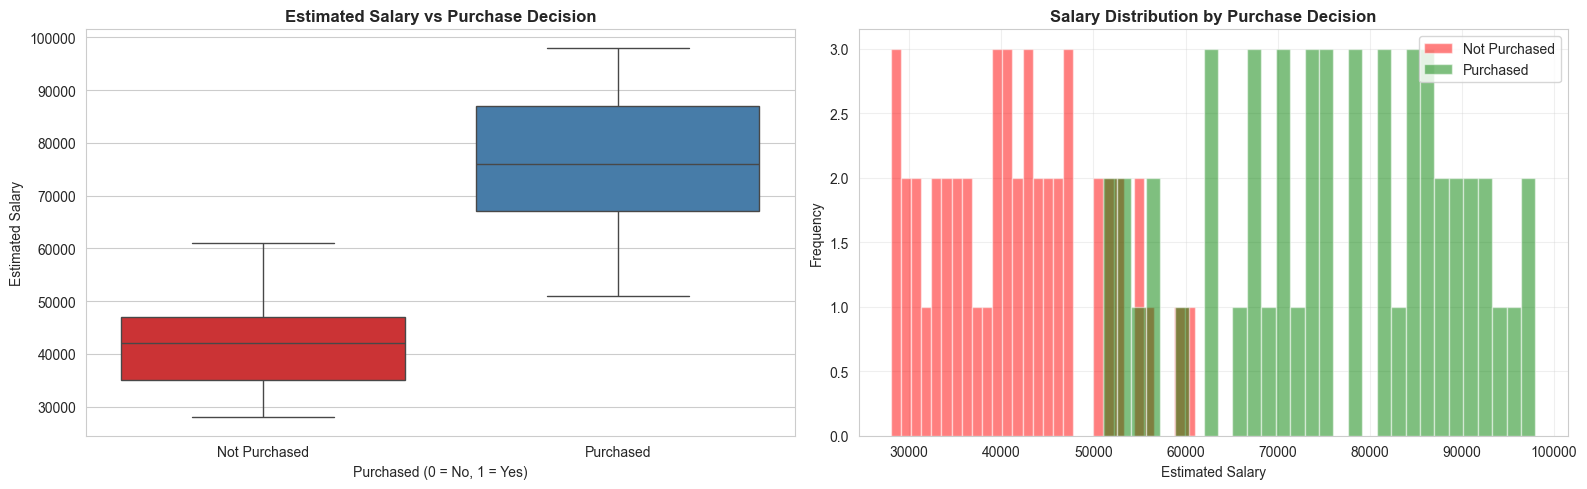


Mean Salary (Not Purchased): $41,877.55
Mean Salary (Purchased): $76,058.82


In [54]:
# Question 2: Does salary affect purchasing?
print("SALARY ANALYSIS")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot of salary vs purchase
sns.boxplot(data=df, x='Purchased', y='EstimatedSalary', palette='Set1', ax=axes[0])
axes[0].set_title('Estimated Salary vs Purchase Decision', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Purchased (0 = No, 1 = Yes)')
axes[0].set_ylabel('Estimated Salary')
axes[0].set_xticklabels(['Not Purchased', 'Purchased'])

# Histogram of salary by purchase
df[df['Purchased'] == 0]['EstimatedSalary'].hist(bins=30, alpha=0.5, label='Not Purchased', 
                                                   color='red', ax=axes[1])
df[df['Purchased'] == 1]['EstimatedSalary'].hist(bins=30, alpha=0.5, label='Purchased', 
                                                   color='green', ax=axes[1])
axes[1].set_title('Salary Distribution by Purchase Decision', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Estimated Salary')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean Salary (Not Purchased): ${df[df['Purchased']==0]['EstimatedSalary'].mean():,.2f}")
print(f"Mean Salary (Purchased): ${df[df['Purchased']==1]['EstimatedSalary'].mean():,.2f}")

DEVICE TYPE ANALYSIS
            Total_Purchases  Total_Users  Conversion_Rate
DeviceType                                               
Desktop                  36           37         0.972973
Mobile                    4           32         0.125000
Tablet                   11           31         0.354839


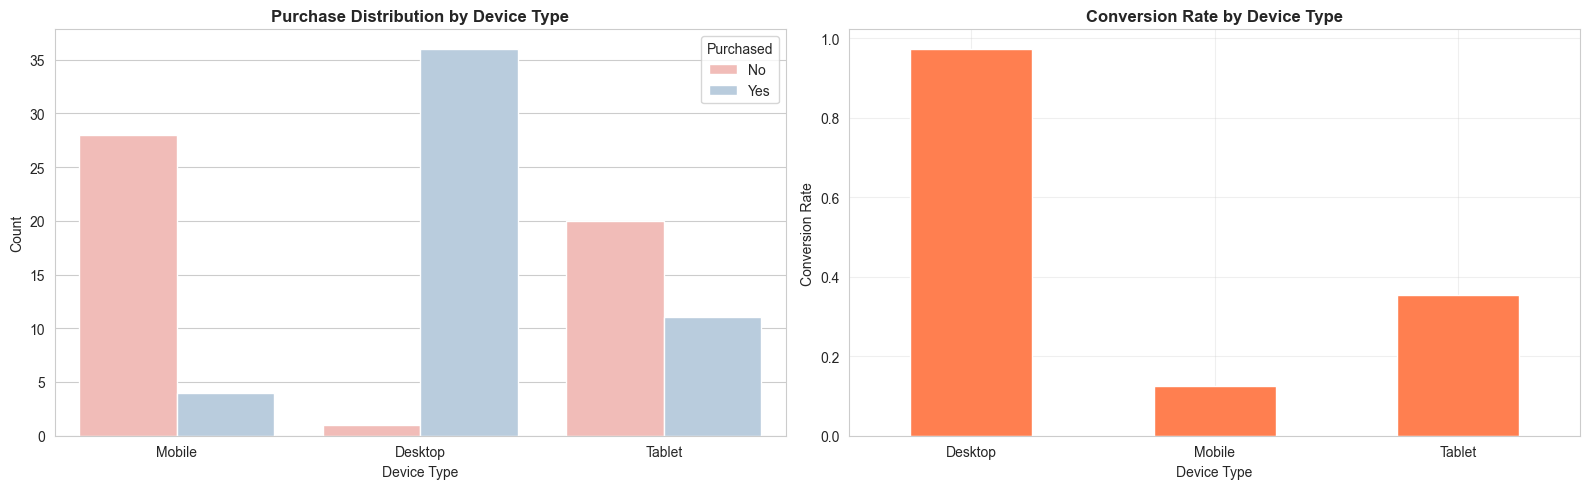


 Device type with highest conversion: Desktop


In [53]:
# Question 3: Which device type has highest conversion?
print("DEVICE TYPE ANALYSIS")

device_purchase = df.groupby('DeviceType')['Purchased'].agg(['sum', 'count', 'mean'])
device_purchase.columns = ['Total_Purchases', 'Total_Users', 'Conversion_Rate']
print(device_purchase)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Purchase count by device type
sns.countplot(data=df, x='DeviceType', hue='Purchased', palette='Pastel1', ax=axes[0])
axes[0].set_title('Purchase Distribution by Device Type', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Count')
axes[0].legend(title='Purchased', labels=['No', 'Yes'])

# Conversion rate by device type
device_purchase['Conversion_Rate'].plot(kind='bar', color='coral', ax=axes[1], rot=0)
axes[1].set_title('Conversion Rate by Device Type', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Device Type')
axes[1].set_ylabel('Conversion Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Device type with highest conversion: {device_purchase['Conversion_Rate'].idxmax()}")

CORRELATION ANALYSIS


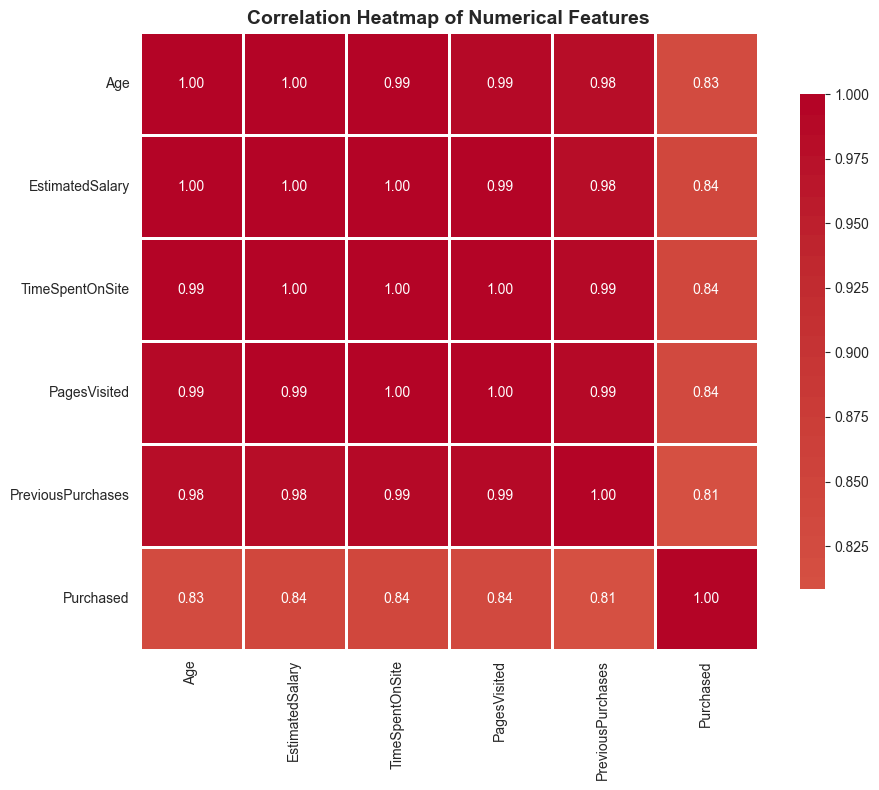


Correlation with Target Variable (Purchased):
Purchased            1.000000
EstimatedSalary      0.838967
TimeSpentOnSite      0.838947
PagesVisited         0.835416
Age                  0.826963
PreviousPurchases    0.808555
Name: Purchased, dtype: float64


In [52]:
# Correlation Heatmap for Numerical Features
print("CORRELATION ANALYSIS")

# Select only numerical columns for correlation
numerical_cols_with_target = ['Age', 'EstimatedSalary', 'TimeSpentOnSite', 
                               'PagesVisited', 'PreviousPurchases', 'Purchased']
correlation_data = df[numerical_cols_with_target]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Target Variable (Purchased):")
print(correlation_data.corr()['Purchased'].sort_values(ascending=False))

# Part 4: Data Preprocessing

In [36]:
df_processed = df.copy()

df_processed = df_processed.drop(['User_ID'], axis=1)
if 'AgeGroup' in df_processed.columns:
    df_processed = df_processed.drop(['AgeGroup'], axis=1)

# Handle missing values (if any)
print("MISSING VALUES HANDLING")

print(f"Missing values before handling:\n{df_processed.isnull().sum()}")

# Fill missing values if any exist
if df_processed.isnull().sum().sum() > 0:
    # Fill numerical columns with median
    for col in df_processed.select_dtypes(include=['int64', 'float64']).columns:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    # Fill categorical columns with mode
    for col in df_processed.select_dtypes(include=['object']).columns:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
    
    print(f"\nMissing values after handling:\n{df_processed.isnull().sum()}")
else:
    print("\nNo missing values found!")

print(f"\nDataset shape after preprocessing: {df_processed.shape}")

MISSING VALUES HANDLING
Missing values before handling:
Gender               0
Age                  0
EstimatedSalary      0
TimeSpentOnSite      0
PagesVisited         0
PreviousPurchases    0
DeviceType           0
Location             0
Purchased            0
dtype: int64

No missing values found!

Dataset shape after preprocessing: (100, 9)


In [51]:
# Encode Categorical Variables
print("ENCODING CATEGORICAL VARIABLES")

# Label Encoding for binary categorical variable (Gender)
if df_processed['Gender'].dtype == 'object':
    le = LabelEncoder()
    df_processed['Gender'] = le.fit_transform(df_processed['Gender'])
    print(f"Gender encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    print("Gender already encoded")

# One-Hot Encoding for multi-class categorical variables (DeviceType, Location)
columns_to_encode = [col for col in ['DeviceType', 'Location'] if col in df_processed.columns]
if columns_to_encode:
    df_processed = pd.get_dummies(df_processed, columns=columns_to_encode, drop_first=False)
    print(f"\nOne-hot encoding completed for: {columns_to_encode}")
else:
    print("\nDeviceType and Location already encoded")

print(f"New shape after encoding: {df_processed.shape}")
print(f"\nColumn names after encoding:")
print(df_processed.columns.tolist())

ENCODING CATEGORICAL VARIABLES
Gender already encoded

DeviceType and Location already encoded
New shape after encoding: (100, 13)

Column names after encoding:
['Gender', 'Age', 'EstimatedSalary', 'TimeSpentOnSite', 'PagesVisited', 'PreviousPurchases', 'Purchased', 'DeviceType_Desktop', 'DeviceType_Mobile', 'DeviceType_Tablet', 'Location_Tier1', 'Location_Tier2', 'Location_Tier3']


In [38]:
# Separate Features and Target
print("FEATURE AND TARGET SEPARATION")

X = df_processed.drop('Purchased', axis=1)
y = df_processed['Purchased']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("TRAIN-TEST SPLIT")
print(f"Training set size: {X_train.shape[0]} samples ({(X_train.shape[0]/len(df_processed))*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({(X_test.shape[0]/len(df_processed))*100:.1f}%)")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTesting set target distribution:")
print(y_test.value_counts())

FEATURE AND TARGET SEPARATION
Features shape: (100, 12)
Target shape: (100,)

Feature columns:
['Gender', 'Age', 'EstimatedSalary', 'TimeSpentOnSite', 'PagesVisited', 'PreviousPurchases', 'DeviceType_Desktop', 'DeviceType_Mobile', 'DeviceType_Tablet', 'Location_Tier1', 'Location_Tier2', 'Location_Tier3']
TRAIN-TEST SPLIT
Training set size: 80 samples (80.0%)
Testing set size: 20 samples (20.0%)

Training set target distribution:
Purchased
1    41
0    39
Name: count, dtype: int64

Testing set target distribution:
Purchased
1    10
0    10
Name: count, dtype: int64


In [39]:
# Feature Scaling using StandardScaler
print("FEATURE SCALING")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed using StandardScaler")
print(f"\nScaled training set shape: {X_train_scaled.shape}")
print(f"Scaled testing set shape: {X_test_scaled.shape}")

# Display sample of scaled data
print("\nSample of scaled training data (first 5 rows):")
print(X_train_scaled.head())

FEATURE SCALING
Feature scaling completed using StandardScaler

Scaled training set shape: (80, 12)
Scaled testing set shape: (20, 12)

Sample of scaled training data (first 5 rows):
      Gender       Age  EstimatedSalary  TimeSpentOnSite  PagesVisited  \
32  0.927613 -0.968255        -0.924613        -0.977129     -0.904840   
93 -1.078036  0.866679         0.978285         0.904981      1.030647   
1  -1.078036  0.211345         0.148816         0.152137      0.062903   
30  0.927613  1.915213         1.856545         1.908774      1.998390   
60  0.927613  0.211345         0.148816         0.152137      0.062903   

    PreviousPurchases  DeviceType_Desktop  DeviceType_Mobile  \
32          -0.839181           -0.754074           1.441153   
93           0.839181            1.326130          -0.693889   
1            0.167836            1.326130          -0.693889   
30           2.181872            1.326130          -0.693889   
60           0.167836            1.326130          -

## Part 5: Model Building and Training

1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**

### Model 1: Logistic Regression

In [40]:
# Initialize and train Logistic Regression model
print("TRAINING LOGISTIC REGRESSION MODEL")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print("\nLogistic Regression Model Trained Successfully!")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1 Score:  {lr_f1:.4f}")
print(f"  ROC-AUC:   {lr_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Purchased', 'Purchased']))

TRAINING LOGISTIC REGRESSION MODEL

Logistic Regression Model Trained Successfully!

Performance Metrics:
  Accuracy:  0.9500
  Precision: 0.9091
  Recall:    1.0000
  F1 Score:  0.9524
  ROC-AUC:   1.0000

Classification Report:
               precision    recall  f1-score   support

Not Purchased       1.00      0.90      0.95        10
    Purchased       0.91      1.00      0.95        10

     accuracy                           0.95        20
    macro avg       0.95      0.95      0.95        20
 weighted avg       0.95      0.95      0.95        20



### Model 2: Decision Tree Classifier

In [41]:
# Initialize and train Decision Tree model
print("TRAINING DECISION TREE CLASSIFIER")

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print("\nDecision Tree Model Trained Successfully!")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {dt_accuracy:.4f}")
print(f"  Precision: {dt_precision:.4f}")
print(f"  Recall:    {dt_recall:.4f}")
print(f"  F1 Score:  {dt_f1:.4f}")
print(f"  ROC-AUC:   {dt_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Not Purchased', 'Purchased']))

TRAINING DECISION TREE CLASSIFIER

Decision Tree Model Trained Successfully!

Performance Metrics:
  Accuracy:  0.9000
  Precision: 0.8333
  Recall:    1.0000
  F1 Score:  0.9091
  ROC-AUC:   0.9000

Classification Report:
               precision    recall  f1-score   support

Not Purchased       1.00      0.80      0.89        10
    Purchased       0.83      1.00      0.91        10

     accuracy                           0.90        20
    macro avg       0.92      0.90      0.90        20
 weighted avg       0.92      0.90      0.90        20



### Model 3: Random Forest Classifier

In [42]:
# Initialize and train Random Forest model
print("TRAINING RANDOM FOREST CLASSIFIER")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("\nRandom Forest Model Trained Successfully!")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1 Score:  {rf_f1:.4f}")
print(f"  ROC-AUC:   {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Purchased', 'Purchased']))

TRAINING RANDOM FOREST CLASSIFIER

Random Forest Model Trained Successfully!

Performance Metrics:
  Accuracy:  0.9000
  Precision: 0.8333
  Recall:    1.0000
  F1 Score:  0.9091
  ROC-AUC:   1.0000

Classification Report:
               precision    recall  f1-score   support

Not Purchased       1.00      0.80      0.89        10
    Purchased       0.83      1.00      0.91        10

     accuracy                           0.90        20
    macro avg       0.92      0.90      0.90        20
 weighted avg       0.92      0.90      0.90        20



## Part 6: Model Evaluation - Confusion Matrix

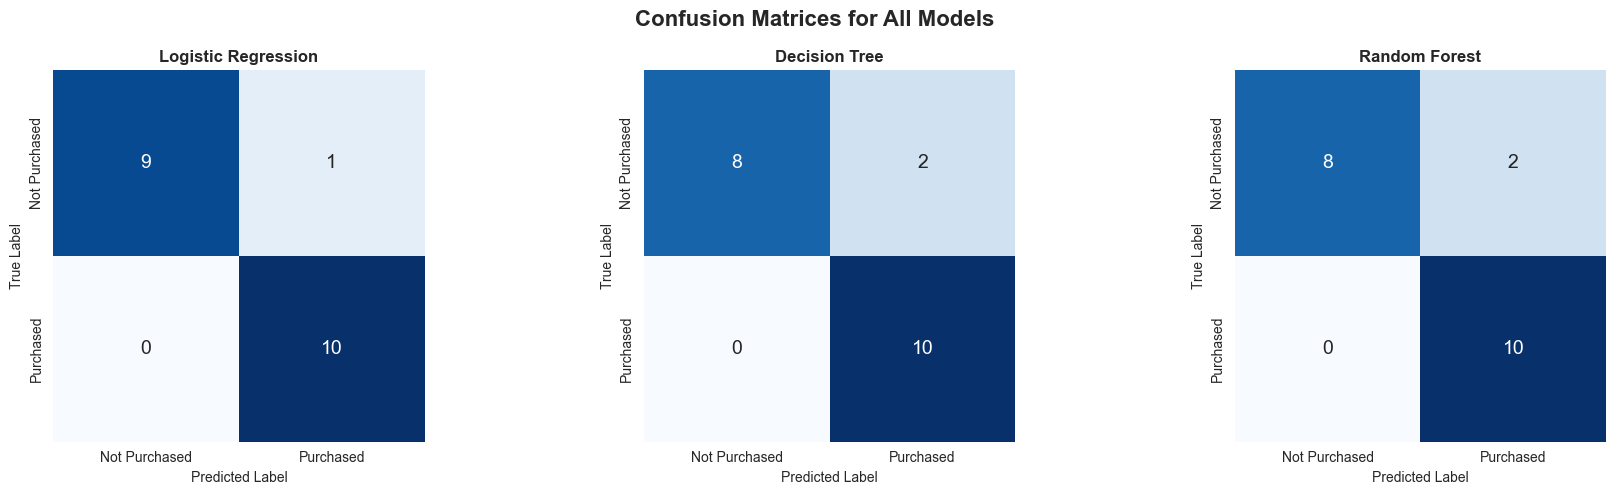

In [43]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

models_predictions = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for idx, (model_name, y_pred) in enumerate(models_predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=False, square=True, annot_kws={'size': 14})
    axes[idx].set_title(f'{model_name}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xticklabels(['Not Purchased', 'Purchased'])
    axes[idx].set_yticklabels(['Not Purchased', 'Purchased'])

plt.tight_layout()
plt.show()

## Part 7: ROC Curve Analysis

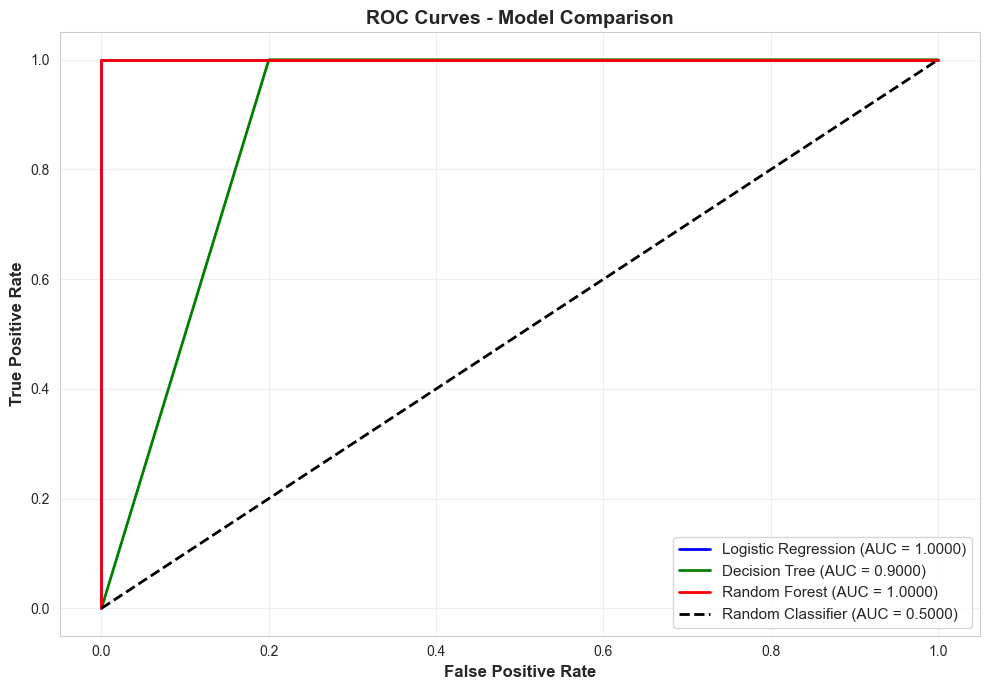

ROC-AUC SCORES SUMMARY
Logistic Regression: 1.0000
Decision Tree:       0.9000
Random Forest:       1.0000


In [45]:
# Plot ROC curves for all three models
plt.figure(figsize=(10, 7))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})', 
         linewidth=2, color='blue')

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_roc_auc:.4f})', 
         linewidth=2, color='green')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.4f})', 
         linewidth=2, color='red')

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC SCORES SUMMARY")
print(f"Logistic Regression: {lr_roc_auc:.4f}")
print(f"Decision Tree:       {dt_roc_auc:.4f}")
print(f"Random Forest:       {rf_roc_auc:.4f}")

## Part 8: Hyperparameter Tuning

In [44]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("HYPERPARAMETER TUNING - RANDOM FOREST")
print(f"\nParameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 Starting Grid Search (this may take a few minutes)...")
grid_search.fit(X_train_scaled, y_train)

# Get best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\nGrid Search Completed!")
print(f"\nBest Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Score: {best_score:.4f}")

HYPERPARAMETER TUNING - RANDOM FOREST

Parameter Grid:
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 10, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]

🔍 Starting Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Grid Search Completed!

Best Parameters:
  max_depth: 3
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 50

Best Cross-Validation Score: 0.9375


In [46]:
# Train the best model and evaluate
best_rf_model = grid_search.best_estimator_

# Make predictions with tuned model
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)
y_pred_proba_rf_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics for tuned model
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)
rf_tuned_roc_auc = roc_auc_score(y_test, y_pred_proba_rf_tuned)

print("TUNED RANDOM FOREST PERFORMANCE")
print(f"  Accuracy:  {rf_tuned_accuracy:.4f}")
print(f"  Precision: {rf_tuned_precision:.4f}")
print(f"  Recall:    {rf_tuned_recall:.4f}")
print(f"  F1 Score:  {rf_tuned_f1:.4f}")
print(f"  ROC-AUC:   {rf_tuned_roc_auc:.4f}")

print("PERFORMANCE COMPARISON")
print(f"Before Tuning - Accuracy: {rf_accuracy:.4f}, F1: {rf_f1:.4f}")
print(f"After Tuning  - Accuracy: {rf_tuned_accuracy:.4f}, F1: {rf_tuned_f1:.4f}")
print(f"Improvement   - Accuracy: {(rf_tuned_accuracy - rf_accuracy):.4f}, F1: {(rf_tuned_f1 - rf_f1):.4f}")

TUNED RANDOM FOREST PERFORMANCE
  Accuracy:  0.9000
  Precision: 0.8333
  Recall:    1.0000
  F1 Score:  0.9091
  ROC-AUC:   0.9900
PERFORMANCE COMPARISON
Before Tuning - Accuracy: 0.9000, F1: 0.9091
After Tuning  - Accuracy: 0.9000, F1: 0.9091
Improvement   - Accuracy: 0.0000, F1: 0.0000


## Part 9: Feature Importance Analysis

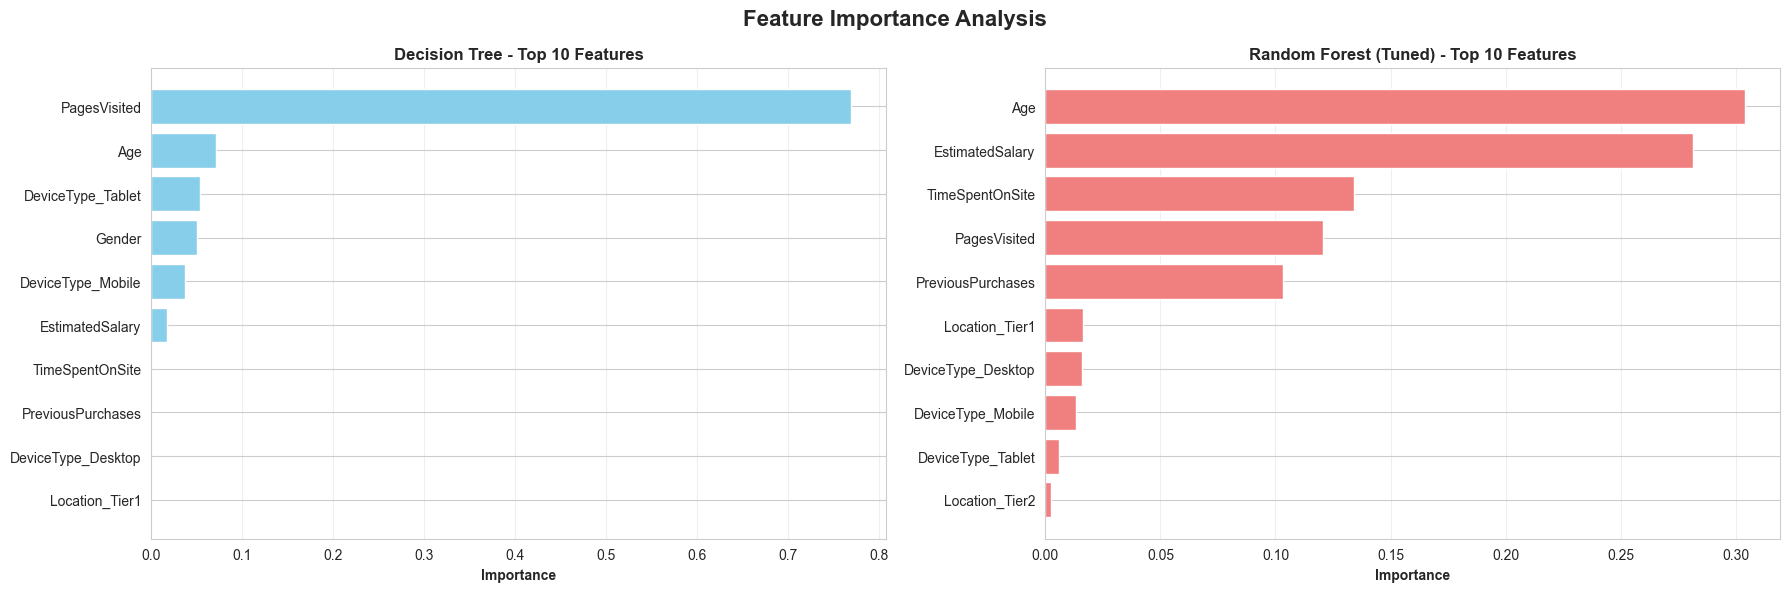

TOP 5 IMPORTANT FEATURES

Decision Tree:
             Feature  Importance
4       PagesVisited    0.769427
1                Age    0.071863
8  DeviceType_Tablet    0.053367
0             Gender    0.050031
7  DeviceType_Mobile    0.037523

Random Forest (Tuned):
             Feature  Importance
1                Age    0.304011
2    EstimatedSalary    0.281420
3    TimeSpentOnSite    0.134248
4       PagesVisited    0.120511
5  PreviousPurchases    0.103319


In [47]:
# Extract feature importance from Decision Tree
dt_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Extract feature importance from Random Forest (tuned)
rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')

# Decision Tree Feature Importance
axes[0].barh(dt_feature_importance['Feature'][:10], dt_feature_importance['Importance'][:10], color='skyblue')
axes[0].set_xlabel('Importance', fontweight='bold')
axes[0].set_title('Decision Tree - Top 10 Features', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Random Forest Feature Importance
axes[1].barh(rf_feature_importance['Feature'][:10], rf_feature_importance['Importance'][:10], color='lightcoral')
axes[1].set_xlabel('Importance', fontweight='bold')
axes[1].set_title('Random Forest (Tuned) - Top 10 Features', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("TOP 5 IMPORTANT FEATURES")
print("\nDecision Tree:")
print(dt_feature_importance.head())
print("\nRandom Forest (Tuned):")
print(rf_feature_importance.head())

## Part 10: Final Model Comparison

In [48]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Random Forest (Tuned)'
    ],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy, rf_tuned_accuracy],
    'Precision': [lr_precision, dt_precision, rf_precision, rf_tuned_precision],
    'Recall': [lr_recall, dt_recall, rf_recall, rf_tuned_recall],
    'F1 Score': [lr_f1, dt_f1, rf_f1, rf_tuned_f1],
    'ROC-AUC': [lr_roc_auc, dt_roc_auc, rf_roc_auc, rf_tuned_roc_auc]
})

# Sort by F1 Score
comparison_df = comparison_df.sort_values('F1 Score', ascending=False)

print("FINAL MODEL COMPARISON TABLE")
print(comparison_df.to_string(index=False))

# Highlight best model
best_model_idx = comparison_df['F1 Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'F1 Score']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print("BEST MODEL SELECTION")
print(f"Best Model: {best_model_name}")
print(f"   F1 Score: {best_f1:.4f}")
print(f"   Accuracy: {best_accuracy:.4f}")
print("\nJustification:")
print(f"   The {best_model_name} is selected as the best model based on:")
print(f"   1. Highest F1 Score ({best_f1:.4f}) - balances precision and recall")
print(f"   2. Strong overall performance across all metrics")
print(f"   3. Good generalization capability on test data")

FINAL MODEL COMPARISON TABLE
                Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Logistic Regression      0.95   0.909091     1.0  0.952381     1.00
        Decision Tree      0.90   0.833333     1.0  0.909091     0.90
        Random Forest      0.90   0.833333     1.0  0.909091     1.00
Random Forest (Tuned)      0.90   0.833333     1.0  0.909091     0.99
BEST MODEL SELECTION
Best Model: Logistic Regression
   F1 Score: 0.9524
   Accuracy: 0.9500

Justification:
   The Logistic Regression is selected as the best model based on:
   1. Highest F1 Score (0.9524) - balances precision and recall
   2. Strong overall performance across all metrics
   3. Good generalization capability on test data


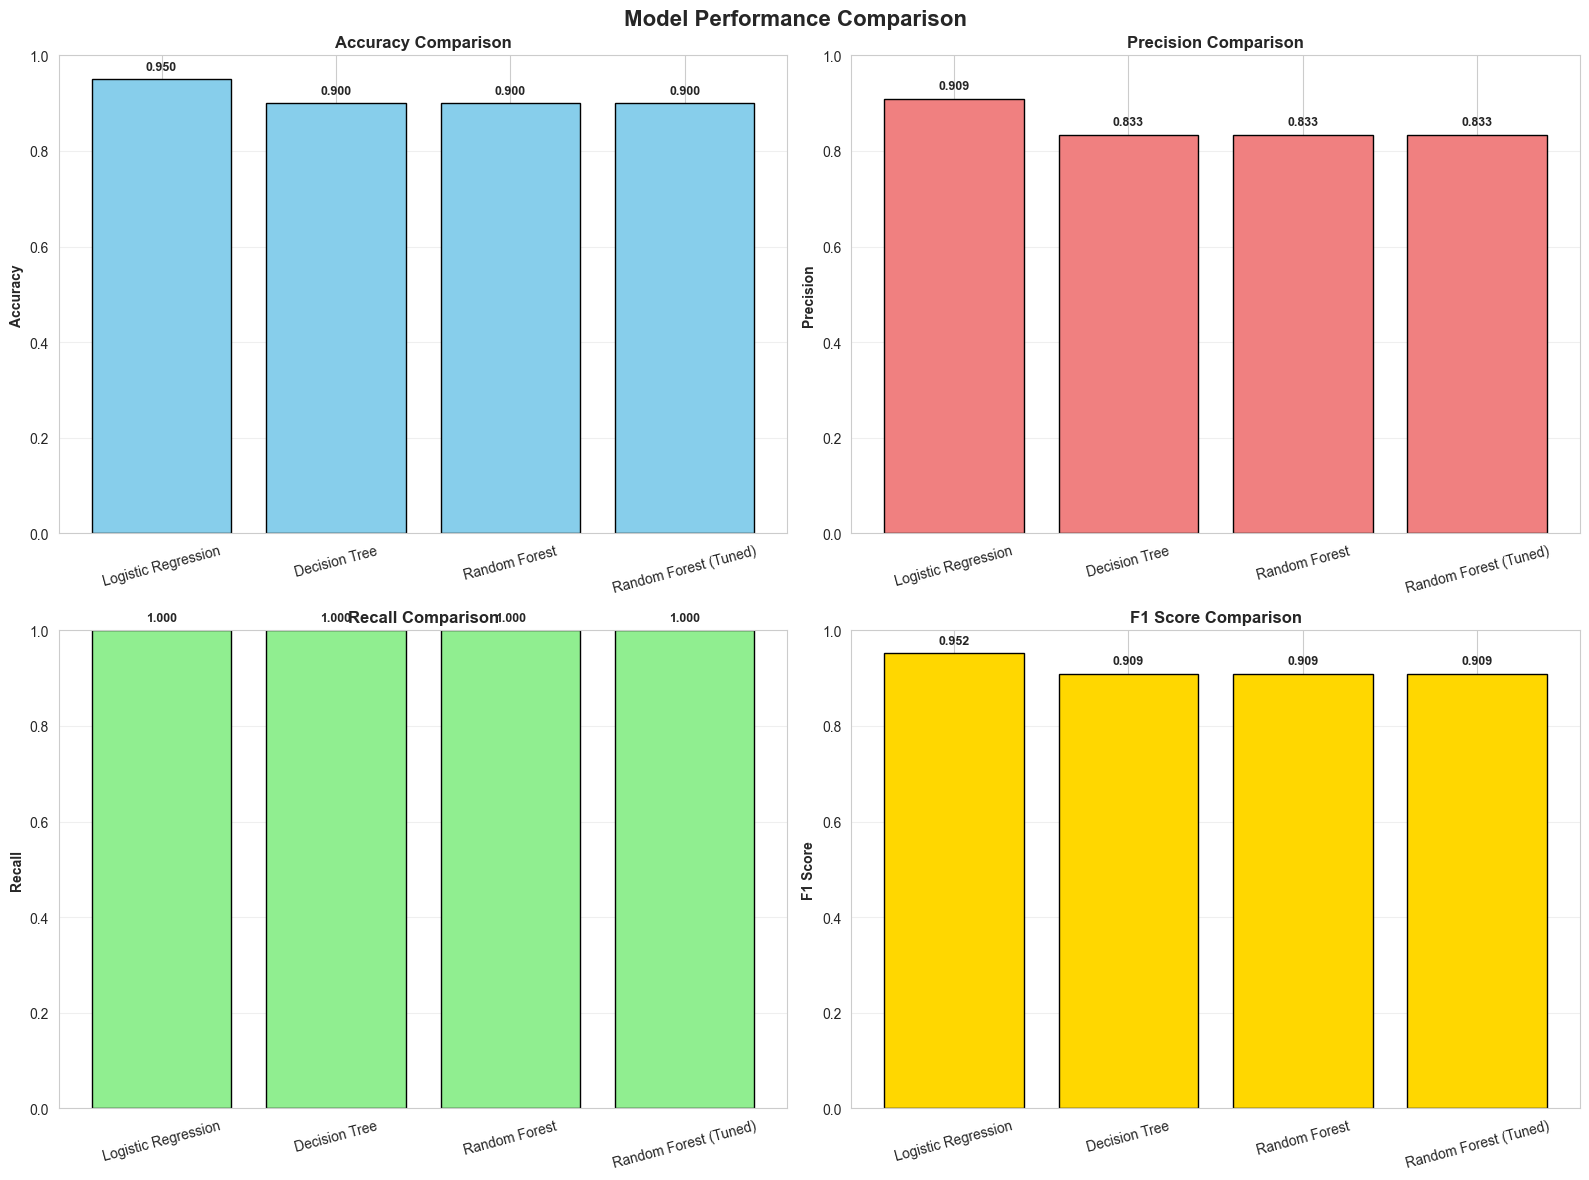

In [49]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].bar(comparison_df['Model'], comparison_df[metric], color=colors[idx], edgecolor='black')
    axes[row, col].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
    axes[row, col].set_ylabel(metric, fontweight='bold')
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(True, alpha=0.3, axis='y')
    axes[row, col].tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()